In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('online_shoppers_intention.csv')

# Look at the first 5 rows to make sure it loaded correctly
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
# Convert categorical text data into numbers (One-Hot Encoding)
df_final = pd.get_dummies(df, drop_first=True)

# Define X (features) and y (target variable 'Revenue')
X = df_final.drop('Revenue', axis=1)
y = df_final['Revenue']

# Check the new shape of our data
print(f"Features shape: {X.shape}")

Features shape: (12330, 26)


In [3]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split!")

Data successfully split!


In [4]:
from sklearn.tree import DecisionTreeClassifier

# 1. Create the Entropy model
entr_model = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)

# 2. Fit (train) the model
entr_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_entr = entr_model.predict(X_test)

In [5]:
# 1. Create the Gini model
gini_model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)

# 2. Fit (train) the model
gini_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_gini = gini_model.predict(X_test)

In [6]:
from sklearn.metrics import classification_report, accuracy_score

print("--- Entropy Model Results ---")
print(classification_report(y_test, y_pred_entr))

print("\n--- Gini Model Results ---")
print(classification_report(y_test, y_pred_gini))

print(f"Entropy Accuracy: {accuracy_score(y_test, y_pred_entr):.2%}")
print(f"Gini Accuracy: {accuracy_score(y_test, y_pred_gini):.2%}")

--- Entropy Model Results ---
              precision    recall  f1-score   support

       False       0.90      0.97      0.93      2055
        True       0.76      0.47      0.58       411

    accuracy                           0.89      2466
   macro avg       0.83      0.72      0.76      2466
weighted avg       0.88      0.89      0.88      2466


--- Gini Model Results ---
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      2055
        True       0.75      0.50      0.60       411

    accuracy                           0.89      2466
   macro avg       0.83      0.73      0.77      2466
weighted avg       0.88      0.89      0.88      2466

Entropy Accuracy: 88.69%
Gini Accuracy: 88.85%


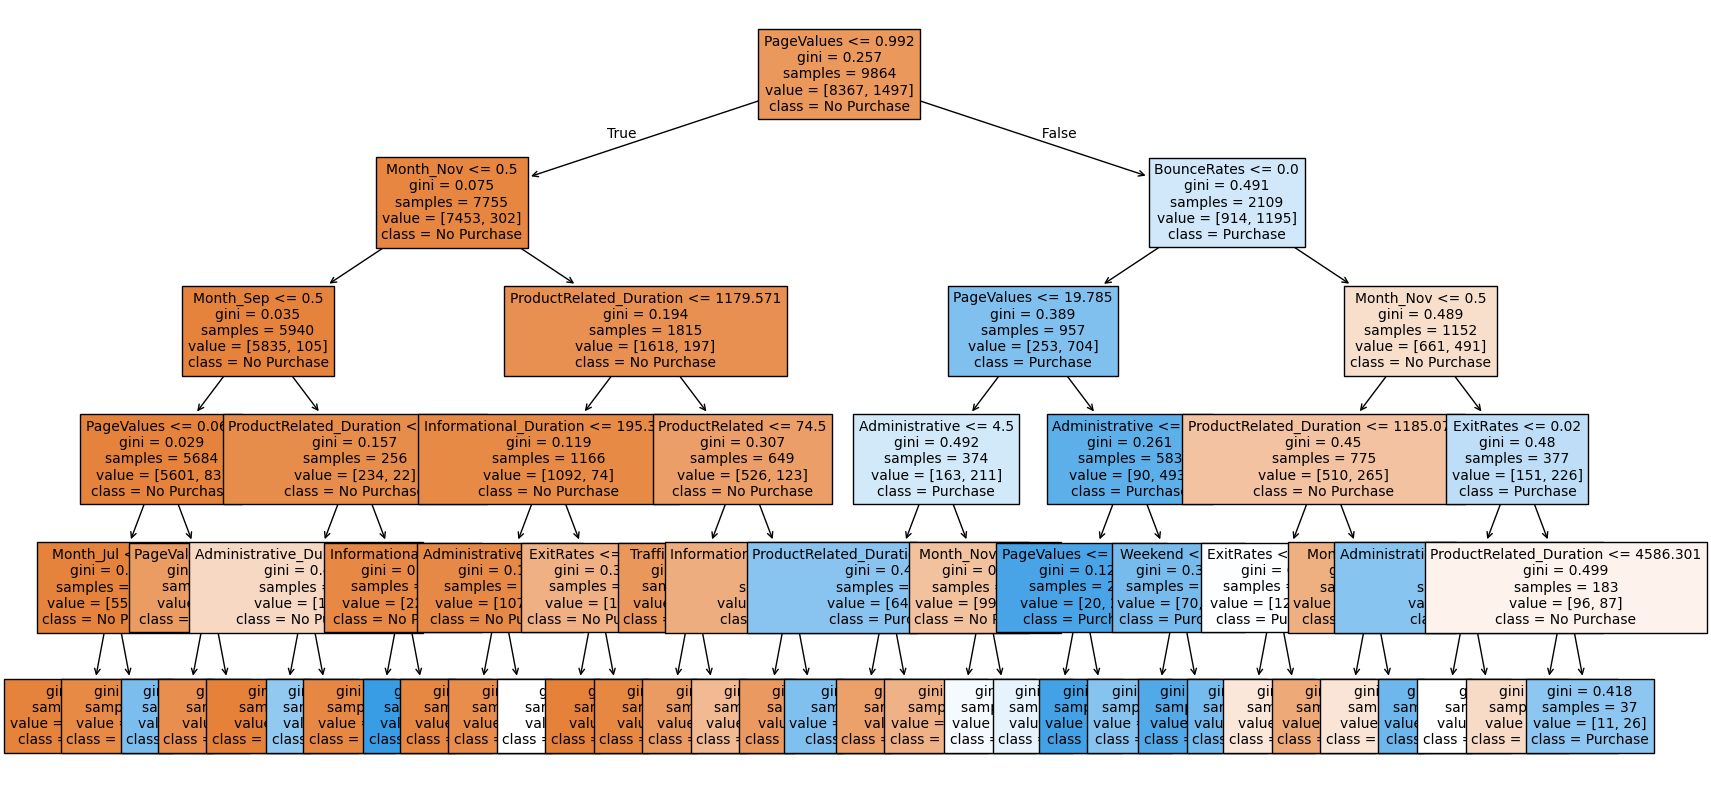

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(gini_model, 
          feature_names=X.columns, 
          class_names=['No Purchase', 'Purchase'], 
          filled=True, 
          fontsize=10)
plt.show()